## Imprints Analysis

In [1]:
import os
import sys
import numpy as np
import matplotlib.pyplot as plt
import plotly.graph_objects as go
import cv2 as cv
import scipy.ndimage
import glob
from tqdm import tqdm
from scipy.interpolate import RectBivariateSpline
from scipy import stats, optimize, signal, special
from scipy.signal import butter, lfilter, find_peaks
from scipy.ndimage import gaussian_filter
from matplotlib import cm, colors
from matplotlib.ticker import LinearLocator
from matplotlib.colors import LogNorm
import imageio.v2 as imageio
from PIL import Image, ImageColor

import darkfield
from darkfield import rossendorfer_farbenliste as rofl

outdir = './Figures'
os.makedirs(outdir, exist_ok=True)

# Matplotlib customizations
SMALL_SIZE = 14
MEDIUM_SIZE = 16
BIGGER_SIZE = 20
plt.rc('font', size=16)
plt.rc('axes', titlesize=MEDIUM_SIZE)
plt.rc('axes', labelsize=16)
plt.rc('xtick', labelsize=12)
plt.rc('ytick', labelsize=12)
plt.rc('legend', fontsize=12)
plt.rcParams['lines.linewidth'] = 2
plt.rcParams['figure.figsize'] = [15, 5]
plt.rcParams["figure.autolayout"] = True

# Theoritical Functions for focus profile fits,  by <i>F. Karbstein</i>
## <span style="color:#007bff;"><b>No obstacle i.e. Airy focus profile.</b></span>

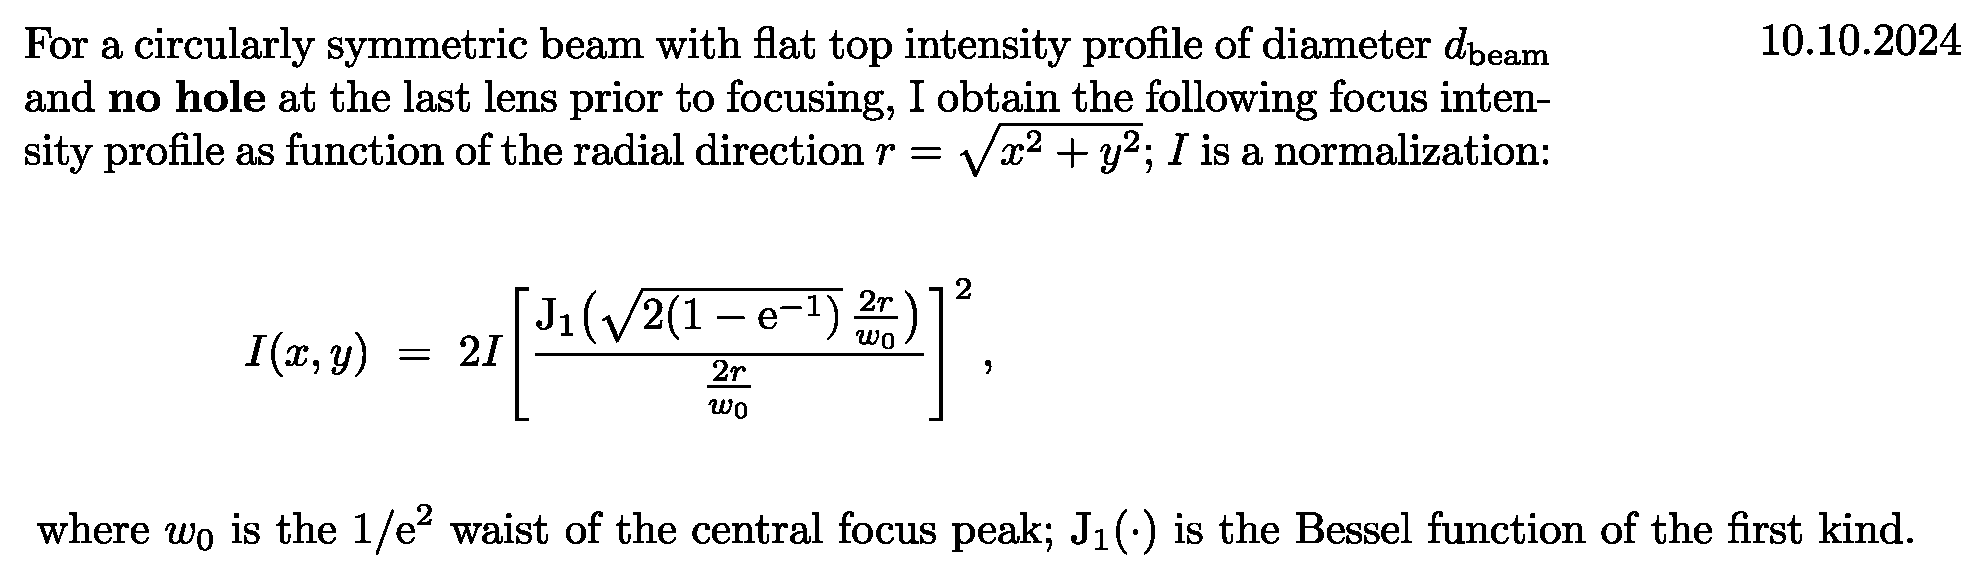

In [2]:
###### Felix's Airy Function ######
def I_x(I0, x, w0):
    x = np.asarray(x)
    result = np.empty_like(x, dtype=float)

    jr = np.sqrt(2 * (1 - 1/np.e)) * 2 * x / w0
    zero_mask = x == 0

    # Handle non-zero x values
    result[~zero_mask] = 2 * I0 * (special.jv(1, jr[~zero_mask]) / (2 * x[~zero_mask] / w0))**2

    # Handle x == 0
    result[zero_mask] = (np.sqrt(2 * (1 - 1/np.e)) / 2)**2 * 2 * I0  # Make output continuous

    return result

###### suoer gaussian function to add as pedstal (ASE) ########
def super_gaussian(x, amplitude, sigma, expon):
    return (amplitude*np.exp(-1*abs(x)**expon /2/ sigma**expon))
    
###### smoothing function for the rough imprint data, moving avg ###### 
def smooth(y, box_pts):
    box = np.ones(box_pts)/box_pts
    y_smooth = np.convolve(y, box, mode='same')
    return y_smooth

In [3]:
# same size as the image size in [um]
x_vals_nO = np.linspace(-4975, 4975, 1726)

lineout_th = I_x(1, x_vals_nO, 120)
ase_n = super_gaussian(x_vals_nO, 0.063, 850.0, 4.0)
fit_n = ase_n + lineout_th

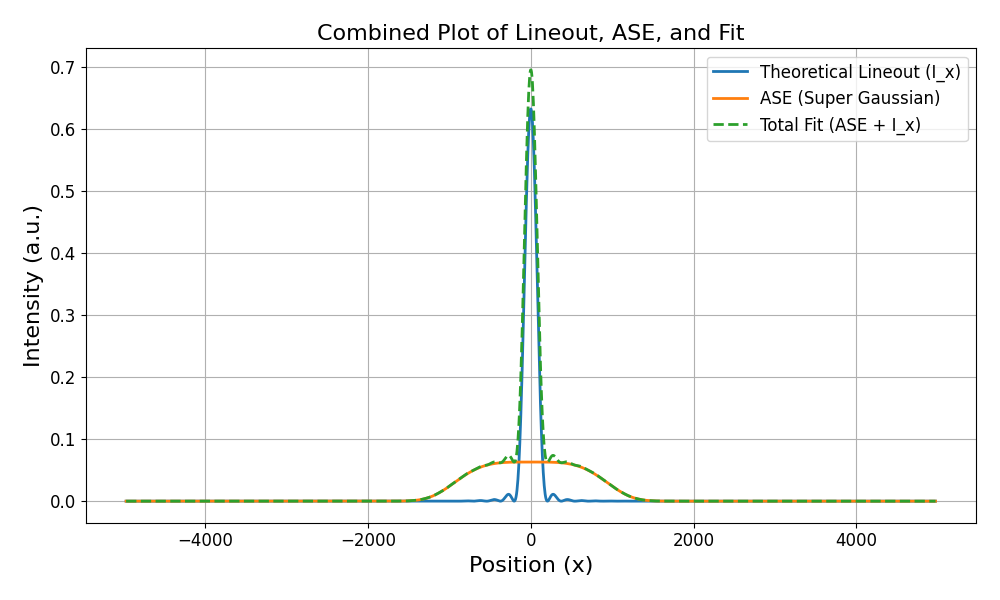

In [22]:
### plot the theory linout ##
%matplotlib widget

plt.figure(figsize=(10, 6))
plt.plot(x_vals_nO , lineout_th, label='Theoretical Lineout (I_x)', linewidth=2)
plt.plot(x_vals_nO , ase_n, label='ASE (Super Gaussian)', linewidth=2)
plt.plot(x_vals_nO , fit_n, label='Total Fit (ASE + I_x)', linestyle='--', linewidth=2)

plt.xlabel('Position (x)')
plt.ylabel('Intensity (a.u.)')
plt.title('Combined Plot of Lineout, ASE, and Fit')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [21]:
 fig = go.Figure()

 fig.add_trace(go.Scatter(x=x_vals_nO, y=lineout_th, mode='lines', name='Theoretical Lineout (I_x)'))
 fig.add_trace(go.Scatter(x=x_vals_nO, y=ase_n, mode='lines', name='ASE (Super Gaussian)'))
 fig.add_trace(go.Scatter(x=x_vals_nO, y=fit_n, mode='lines', name='Total Fit (ASE + I_x)', line=dict(dash='dash')))

 # Layout settings
 fig.update_layout(
     title='Interactive Plot of Lineout, ASE, and Fit',
     xaxis_title='Position (x)',
     yaxis_title='Intensity (a.u.)',
     template='plotly_white',
     legend=dict(x=0.01, y=0.99),
     hovermode='x unified'
 )

## Imprints w/ & w/o an Obstacle

In [6]:
###### function to open the images ######
def load_images_from_paths(image_paths):
    """
    Loads images from a list of file,
    ensures consistent dimensions and channels,
    and returns as a numpy array.
    """
    images = []
    first_img_shape = None

    for path in tqdm(image_paths):
        img = cv.imread(path, -1)  # -1 ensures the image is loaded as is

        if img is None:
            print(f"Warning: Could not load image from {path}. Skipping.")
            continue

        # Convert to grayscale if it's a color image (3 or 4 channels)
        if len(img.shape) == 3 and img.shape[2] in [3, 4]:
            img = cv.cvtColor(img, cv.COLOR_BGR2GRAY)
        elif len(img.shape) == 2:
            # Already grayscale
            pass
        else:
            print(f"Warning: Image {path} has an unexpected number of channels/dimensions: {img.shape}. Skipping.")
            continue

        # Set the target shape based on the first successfully loaded image
        if first_img_shape is None:
            first_img_shape = img.shape
        
        # Resize images to the shape of the first image if they are different
        if img.shape != first_img_shape:
            img = cv.resize(img, (first_img_shape[1], first_img_shape[0])) # cv.resize expects (width, height)

        images.append(np.array(img))
    
    if not images:
        print("No images were successfully loaded.")
        return np.array([]) # Return an empty array if no images were loaded

    return np.array(images)

In [7]:
# Define image paths
# Base directory relative to the script
basedir = os.path.dirname(os.path.abspath('./imprints_analysis'))

# Define path to tif_images
tif_dir = os.path.join(basedir, "imprints", "tif_images")
tif_dir = os.path.normpath(tif_dir)  # Normalize path for Linux/Windows compatibility

#tif_dir = 'darkfield_p5438/notebooks/imprints_analysis/imprints/tif_images/no_obstacle_z=-14p3mm_width=9p95e-06m_240724_210812.tif'
print(tif_dir)

# Get image lists using glob
all_imprint_paths = glob.glob(os.path.join(tif_dir, "*.tif"))
no_obstacle_imprint_paths = glob.glob(os.path.join(tif_dir, "no_*.tif"))
with_obstacle_imprint_paths = glob.glob(os.path.join(tif_dir, "obstacle_*.tif"))

titles = [
    'Full Beam Focus Z=-12.3 mm',
    'Full Beam Focus',
    'Full Beam Focus Z=-14.3 mm',
    'Beam w/ 160um W wire Obstacle Focus Z=-12.3 mm',
    'Beam w/ 160um W wire Obstacle Focus Z=-13.3 mm',
    'Beam Focus w/ 160um W-wire Obstacle'
]

# Load images
all_images = load_images_from_paths(all_imprint_paths)
images_no_obstacle = load_images_from_paths(no_obstacle_imprint_paths)
images_with_obstacle = load_images_from_paths(with_obstacle_imprint_paths)
all_images_dict = dict(zip(titles, all_images))


print(f"Shape of all_images: {all_images.shape}")
print(f"Shape of images_no_obstacle: {images_no_obstacle.shape}")
print(f"Shape of images_with_obstacle: {images_with_obstacle.shape}")

/home/yu79deg/darkfield_p5438/notebooks/imprints_analysis/imprints/tif_images


100%|██████████| 3/3 [00:00<00:00, 10.17it/s]

Shape of all_images: (6, 1588, 1725)
Shape of images_no_obstacle: (3, 1588, 1725)
Shape of images_with_obstacle: (3, 1715, 1862)


In [8]:
print(f"Total images: {len(all_images)}")
print(f"No obstacle images: {len(images_no_obstacle)}")
print(f"With obstacle images: {len(images_with_obstacle)}")



Total images: 6
No obstacle images: 3
With obstacle images: 3


In [9]:
# Image Calibration px --> um for images without Obstacles
calibration_no_obstacle = 9.95 / 1725

# Image Calibration px --> um for images with Obstacles
calibration_with_obstacle = 14.9 / 1862

In [10]:
##### making smooth line out from center of imprints #####
ln_n  = images_no_obstacle[1, 806,:]
data_nO_lineout_smooth = smooth(ln_n[603:1093],4)
data_nO_lineout_normalized = data_nO_lineout_smooth/data_nO_lineout_smooth.max()

In [11]:
test = all_images_dict['Full Beam Focus']

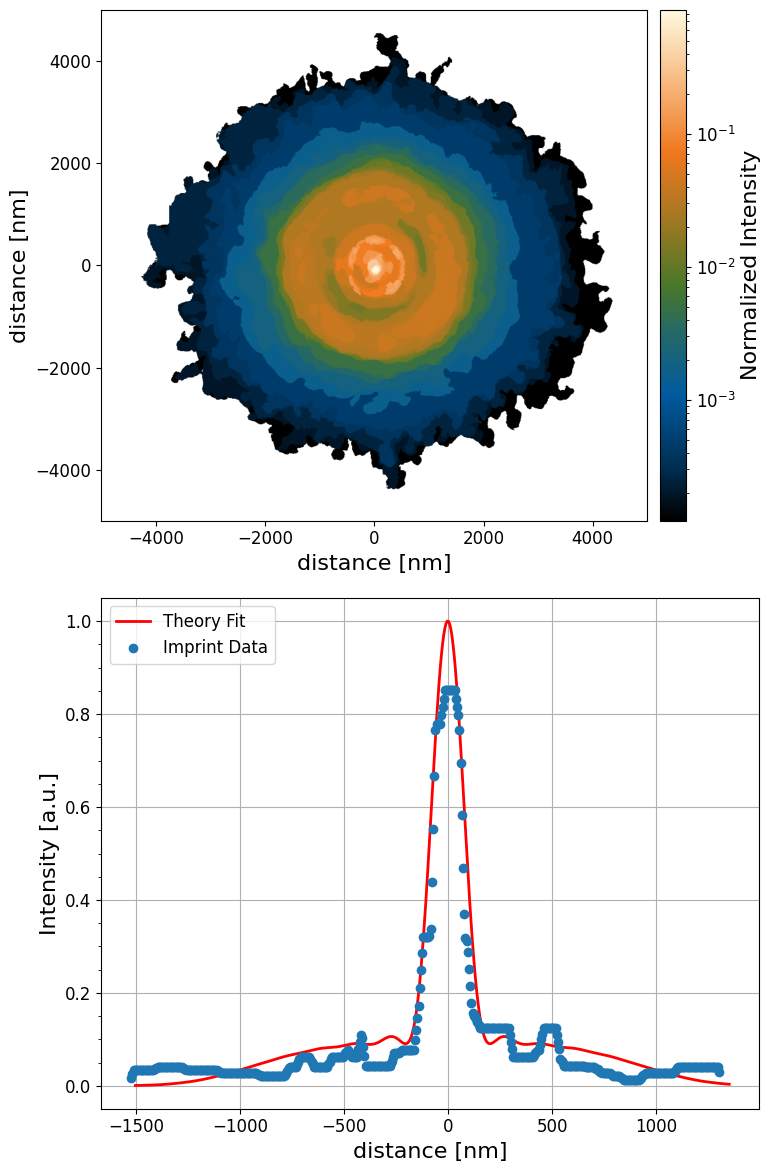

In [12]:
plt.figure(figsize=(8, 12))
plt.subplot(2, 1, 1)
plt.imshow(images_no_obstacle[1], cmap=rofl.cmap(), extent=[-5000, +5000, -5000, +5000], norm=LogNorm(), aspect="auto")
plt.ylabel('distance [nm]')
plt.xlabel('distance [nm]')
plt.colorbar(label='Normalized Intensity', pad=0.02)

# Right subplot – line plots
plt.subplot(2, 1, 2)
plt.plot(np.linspace(-1505, 1350, 500), fit_n[600:1100]/fit_n.max(),'-r', label=r'Theory Fit')
plt.plot(np.linspace(-1525, 1301, 490), data_nO_lineout_smooth, 'o',markersize=6, label='Imprint Data')

plt.yticks(np.arange(0, 1.05, 0.05), minor=True)
plt.ylabel('Intensity [a.u.]')
plt.xlabel('distance [nm]')
plt.grid('both')
plt.legend(loc='upper left')

plt.tight_layout()

# Save to ./Figures directory
save_path = os.path.join(outdir, 'FullBeamFocus_linout.png')
plt.savefig(save_path, bbox_inches='tight')

plt.show()

# Theoritical Functions for focus profile fits,  by <i>F. Karbstein</i>
## <span style="color:#ff9900;"><b>with obstacle i.e.double slit interference profile.</b></span>

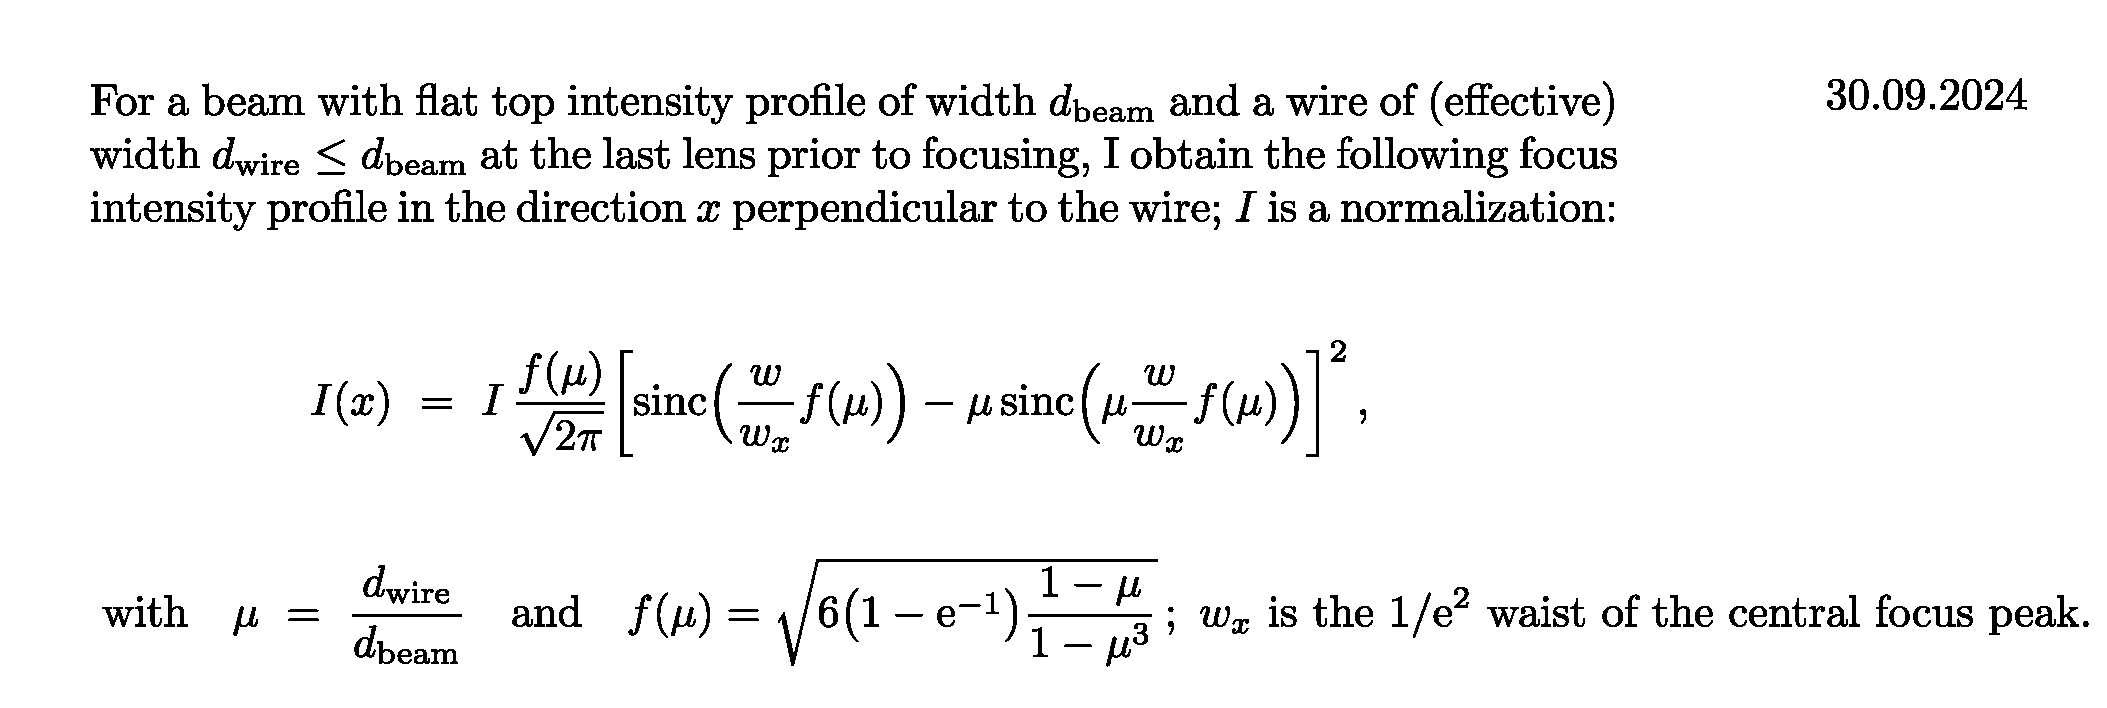

In [13]:
###### Felix's interference Function ######

def f_mu(y):
    """Computes f_mu based on parameter y."""
    return np.sqrt(6 * (1 - np.exp(-1)) * (1 - y) / (1 - y**3))

def sink(x):
    """Computes sin(x)/x with safe handling of x = 0 (sinc function)."""
    x = np.asarray(x)
    result = np.ones_like(x)
    nonzero = x != 0
    result[nonzero] = np.sin(x[nonzero]) / x[nonzero]
    return result

def E_th(I, f, w, w_x, m):
    """
    Computes theoretical field E_th based on:
    - I: intensity
    - f: spatial frequency or scaling factor
    - w: beam width or related spatial scale
    - w_x: reference beam width
    - m: mu (see cell above)
    """
    term1 = sink(w * f / w_x)
    term2 = sink(m * w * f / w_x)
    return I * f * (term1 - m * term2)**2 / np.sqrt(2 * np.pi)

In [15]:
###### Best fitted value for Theory lineout ######
d_beam = 300 # um  can we somehow put in the nearfield from Pop-in?
d_wire = 160 # 160 um 
mu     = d_wire/d_beam
focal  = 438e3 # [um] crl4a focal length
wv = 0.141e-3
x_vals_wO = np.linspace(-7626, 7274, 1862)
x_zoom    = np.linspace(-2000, 2000,1000)
# Compute theoretical intensity profile
I_th_w160 = E_th(6.05, f_mu(mu), w=x_zoom , w_x=75, m=mu)
# Extract region of interest from the intensity profile

#creating theoritical lineout
ase_w = super_gaussian(x_zoom, 0.075,850,4) # some supergaussian pedstal to cosider dranband focus
fit_w = I_th_w160 + ase_w
fit_w = fit_w/fit_w.max() 


### make a smooth lineout from data ###
lineout_w02 = smooth(images_with_obstacle[2,861,419:1543],4)

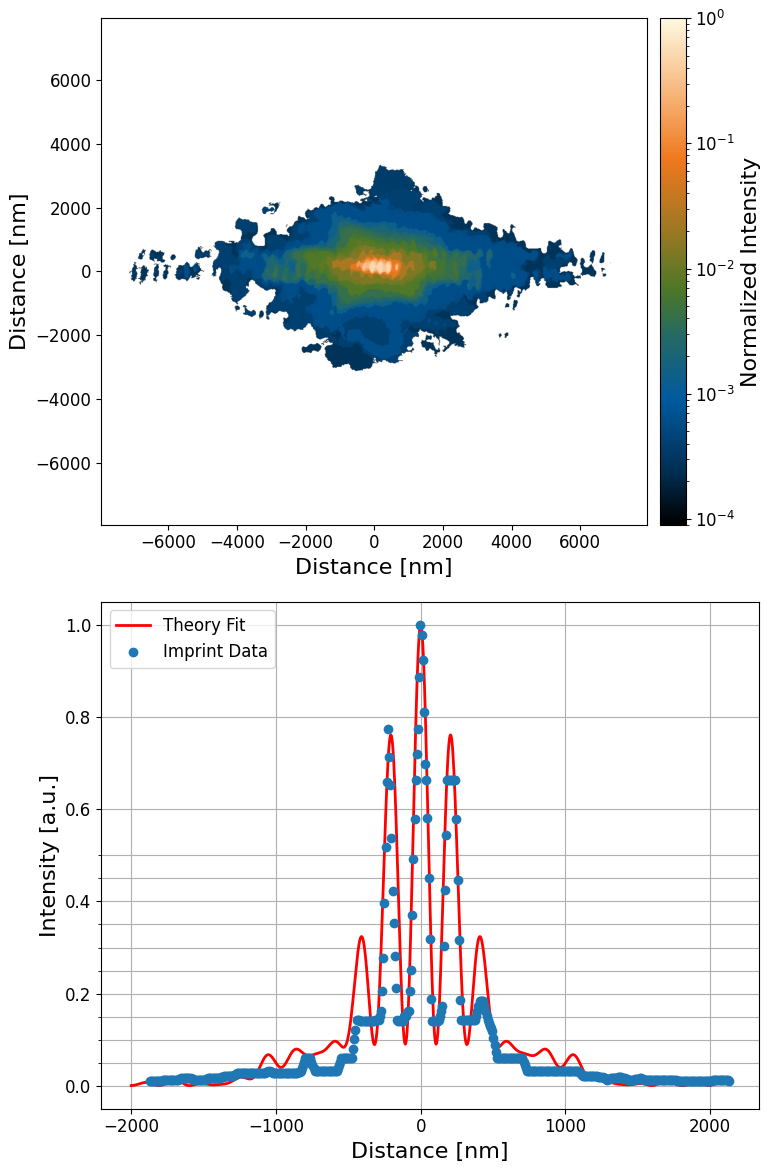

In [16]:
plt.figure(figsize=(8, 12))

# --- Upper subplot: 2D image plot ---
plt.subplot(2, 1, 1)
plt.imshow(images_with_obstacle[2], cmap=rofl.cmap(), aspect="auto", extent=[-7950, 7950, -7950, 7950], norm=LogNorm())
plt.clim(0.9e-4, 1)
plt.xlabel('Distance [nm]')
plt.ylabel('Distance [nm]')
plt.colorbar(label='Normalized Intensity', pad=0.02)
# plt.title(titles[-1])  # Uncomment if needed

# --- Lower subplot: lineouts ---
plt.subplot(2, 1, 2)

x_fit = np.linspace(-2000, 2000, 1000)
x_data = np.linspace(-1870, 2130, 500)
lineout_norm = lineout_w02[300:800] / lineout_w02[300:800].max()

plt.plot(x_fit, fit_w, '-r', label='Theory Fit', lw=2)
plt.plot(x_data, lineout_norm, 'o', label='Imprint Data', markersize=6)

plt.xlabel('Distance [nm]')
plt.ylabel('Intensity [a.u.]')
plt.yticks(np.arange(0, 0.55, 0.05), minor=True)
plt.grid(True, which='both')
plt.legend(loc='upper left')

plt.tight_layout()


# Save to ./Figures directory
save_path = os.path.join(outdir, 'ObsBeamFocus160w_linout.png')
plt.savefig(save_path, bbox_inches='tight')

plt.show()

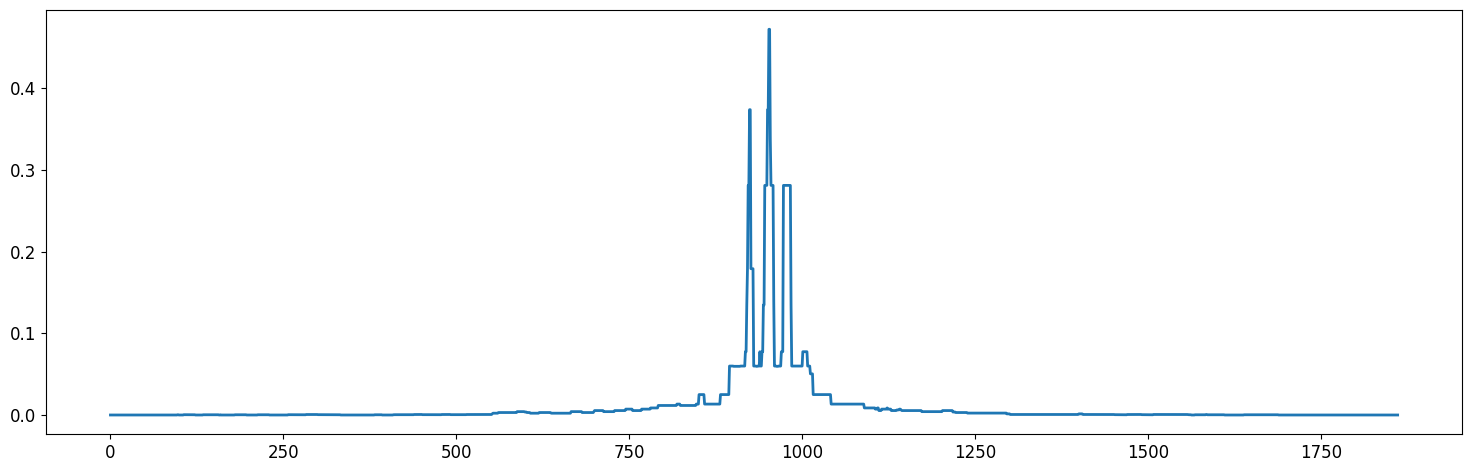

In [20]:
plt.figure()
plt.plot(images_with_obstacle[2,861,:],'-')

